
处理文件 1: Test2_MBES.tif


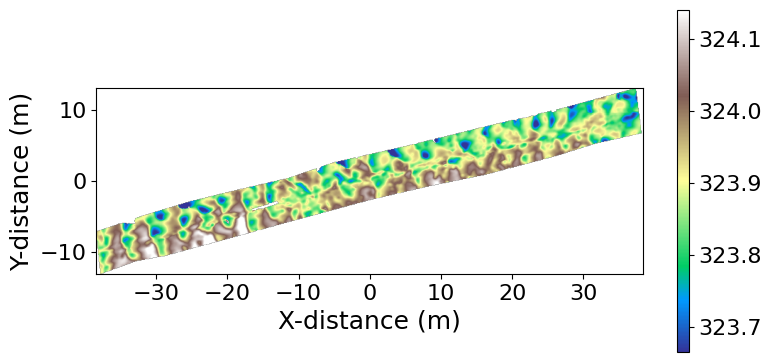

一次旋转到位，最终旋转角度: -14.43度（区间-90°~90°）
旋转后为横向长方形：高446×宽812（宽≥高）
旋转后掩码的有效像素数：49110
裁剪后：总像素=28600, 有效像素占比=99.90%


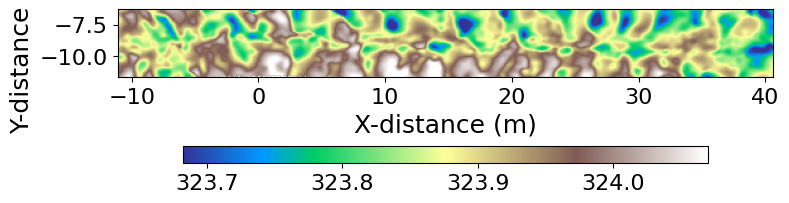

分辨率: dx=0.0997m, dy=0.0997m
内接矩形内有效像素数：28571

===== 线性趋势拟合参数 =====
常数项 a = 323.869017（高程基准值）
x方向系数 b = -0.000145（列方向每像素高程变化率）
y方向系数 c = 0.002312（行方向每像素高程变化率）
拟合残差平方和 = 151.657067（越小拟合越好）



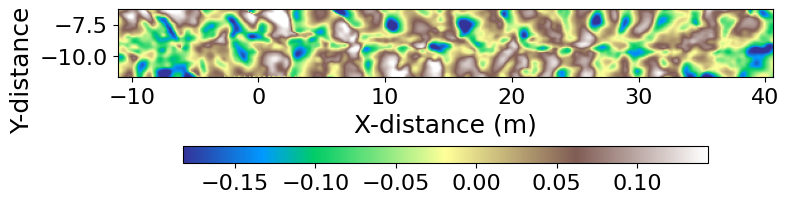

去趋势后图像已保存：MBS_data/TestCase2/output\Test2_MBES_detrend_.png
主峰值 - kx=-0.3280, ky=-0.0000
对称峰值 - kx=0.3280, ky=0.0000
特征波长 λ=3.049m, 方向 θ=14.4°


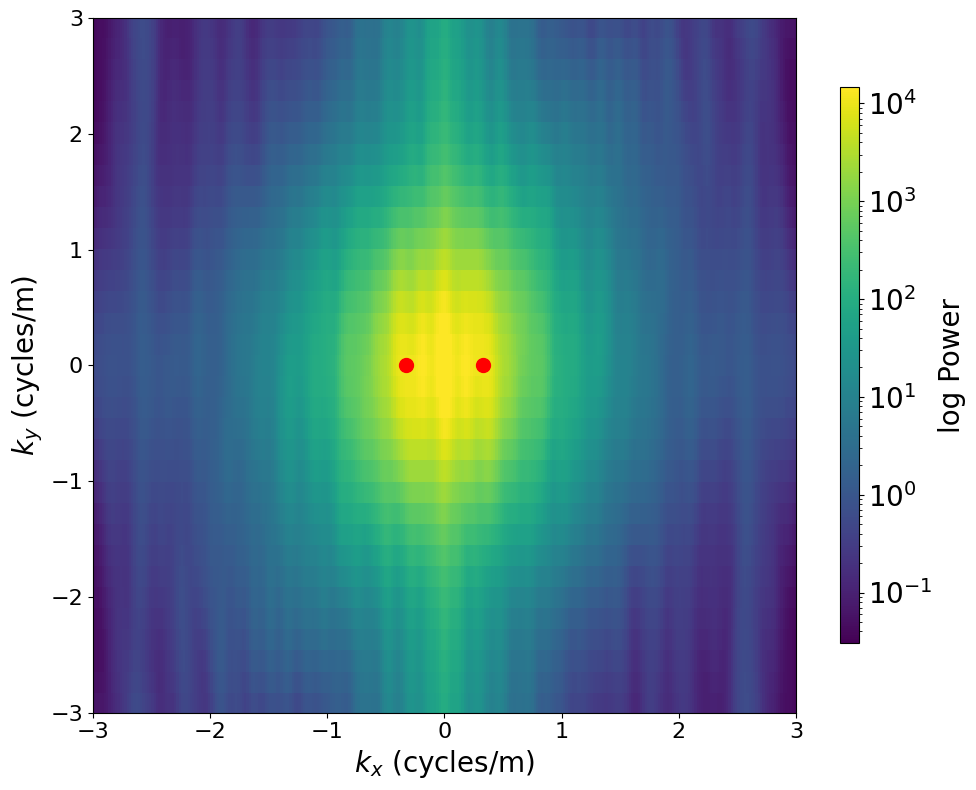

功率谱已保存：MBS_data/TestCase2/output\Test2_MBES_power.png


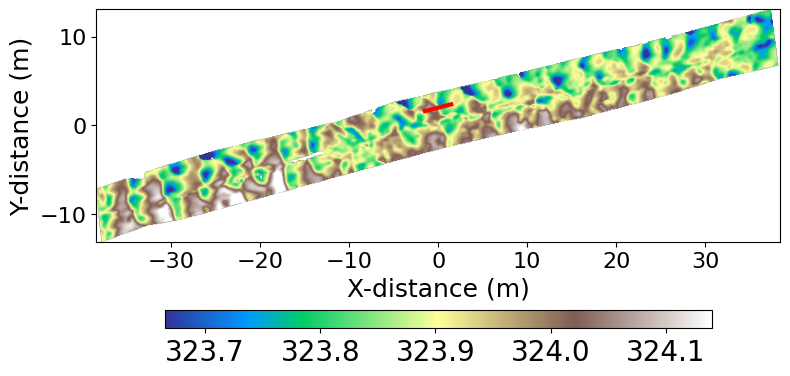

原始底图标注已保存：MBS_data/TestCase2/output\Test2_MBES_base_with_line.png

处理完成！
输出文件目录：MBS_data/TestCase2/output
结果已输出到Excel：MBS_data/TestCase2/output\Test2_MBES_fourier_result.xlsx


In [4]:
# Single DEM process
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import matplotlib.colors as colors
from pyproj import Transformer
from scipy.ndimage import rotate, gaussian_filter
from skimage.measure import regionprops, label
import os


plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# ===================== 配置区（可修改） =====================

#input_tif_path1 = "UAV bedform/20250726/result/Fourier/Uniform12/Uniform12.tif"   # 照片/DEM路径1
#output_root_dir = "UAV bedform/20250726/result/Fourier/Uniform12"

input_tif_path1 = "MBS_data/TestCase2/Test2_MBES.tif"
output_root_dir = "MBS_data/TestCase2/output"

ENABLE_INTERMEDIATE_OUTPUT = True  # 开关：是否输出中间结果
DC_EXCLUDE_RADIUS = 15  # 排除中心直流分量的半径（像素），可调整


# ===================== 工具函数 =====================
def create_output_dir(output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    return output_dir


def find_largest_inscribed_rectangle(mask, max_invalid_ratio=0):
    """
    优化暴力法：严格校验矩形整体无效比例，解决边缘空白，兼容原有接口
    """
    if not np.any(mask):
        return (0, 0, 0, 0)
    
    h, w = mask.shape
    max_area = 0
    best_rect = (0, 0, 0, 0)  # (top_row, bottom_row, left_col, right_col)
    
    # 缩小遍历范围：仅在有效像素外接矩形内遍历
    valid_rows = np.where(np.any(mask, axis=1))[0]
    valid_cols = np.where(np.any(mask, axis=0))[0]
    if len(valid_rows) == 0 or len(valid_cols) == 0:
        return (0, 0, 0, 0)
    min_row, max_row_global = valid_rows.min(), valid_rows.max()
    min_col, max_col_global = valid_cols.min(), valid_cols.max()

    # 遍历所有上下行边界
    for top_row in range(min_row, max_row_global + 1):
        for bottom_row in range(top_row, max_row_global + 1):
            rect_height = bottom_row - top_row + 1
            # 提前剪枝：减少无效计算
            if rect_height * (max_col_global - min_col + 1) <= max_area:
                continue
            
            # 判断每一列是否满足无效比例要求
            col_valid = []
            for col in range(min_col, max_col_global + 1):
                col_pixels = mask[top_row:bottom_row+1, col]
                total_pix = col_pixels.size
                valid_pix = np.sum(col_pixels)
                invalid_ratio = (total_pix - valid_pix) / total_pix if total_pix > 0 else 1
                col_valid.append(invalid_ratio <= max_invalid_ratio)
            
            # 找最长连续有效列
            col_valid = np.array(col_valid)
            current_col_start = min_col
            for col_idx in range(len(col_valid)):
                if not col_valid[col_idx]:
                    current_col_start = min_col + col_idx + 1
                    continue
                current_col_end = min_col + col_idx
                rect_width = current_col_end - current_col_start + 1
                current_area = rect_height * rect_width
                
                # 严格校验矩形整体无效比例（核心：解决边缘空白）
                rect_mask = mask[top_row:bottom_row+1, current_col_start:current_col_end+1]
                total_pixels = rect_mask.size
                valid_pixels = np.sum(rect_mask)
                final_invalid_ratio = (total_pixels - valid_pixels) / total_pixels if total_pixels > 0 else 1
                
                if current_area > max_area and final_invalid_ratio <= max_invalid_ratio:
                    max_area = current_area
                    best_rect = (top_row, bottom_row, current_col_start, current_col_end)

    # 兜底逻辑（保留原有逻辑，避免流程中断）
    if max_area < 100:
        rows = np.where(np.any(mask, axis=1))[0]
        cols = np.where(np.any(mask, axis=0))[0]
        if len(rows) > 0 and len(cols) > 0:
            best_rect = (rows.min(), rows.max(), cols.min(), cols.max())
        else:
            best_rect = (0, mask.shape[0]-1, 0, mask.shape[1]-1)
    
    return best_rect


def crop_valid_rotated(data, nodata, output_rot_mask_path=None):
    if np.isnan(nodata):
        valid_mask = ~np.isnan(data)
    else:
        valid_mask = ~np.isclose(data, nodata) & ~np.isnan(data)
    if not np.any(valid_mask):
        raise ValueError("无有效数据")

    labeled = label(valid_mask)
    props = regionprops(labeled)[0]
    
    # ===================== 修正后的核心：rotate_angle 计算（彻底解决竖向问题） =====================
    # 1. 初始角度计算（保留原逻辑，不改动）
    angle_rad = props.orientation
    angle_deg = angle_rad * 180 / np.pi
    initial_rotate_angle = -angle_deg  # 初始旋转角度

    # 2. 生成一次旋转的候选角度集（仅3个，确保一次旋转到位）
    angle_candidates = [
        initial_rotate_angle,
        initial_rotate_angle + 90,
        initial_rotate_angle - 90
    ]

    # 3. 对每个候选角度：归一化到-90°~90°，并实际验证旋转后的高宽（核心：不猜，实测！）
    candidate_info = []
    for angle in angle_candidates:
        # 步骤1：归一化角度到 -90° ~ 90° 区间
        norm_angle = angle % 180  # 先映射到 0°~179°
        if norm_angle > 90:
            norm_angle -= 180     # 大于90°转为负数（如100°→-80°，170°→-10°）
        
        # 步骤2：实际旋转掩码（掩码数据量小，计算快），直接判断旋转后是否为横向
        # 这是最准确的方式，彻底避免经验阈值错误
        mask_rot_temp = rotate(
            valid_mask.astype(float),
            norm_angle,
            mode='constant',
            cval=0,
            reshape=True,
            order=0
        )
        mask_rot_temp = mask_rot_temp > 0
        h_temp, w_temp = mask_rot_temp.shape  # 获取旋转后的实际高宽
        
        # 步骤3：记录「角度、绝对值、是否横向、高、宽」
        is_horizontal = w_temp >= h_temp  # 宽≥高即为横向（避免近似正方形误判）
        candidate_info.append({
            'norm_angle': norm_angle,
            'abs_angle': abs(norm_angle),
            'is_horizontal': is_horizontal,
            'h': h_temp,
            'w': w_temp
        })

    # 4. 筛选：先过滤出所有横向的候选，再找绝对值最小的角度（核心修正）
    # 第一步：只保留横向的候选
    horizontal_candidates = [info for info in candidate_info if info['is_horizontal']]
    if not horizontal_candidates:
        # 极端情况：无横向候选，默认选绝对值最小的（兜底）
        horizontal_candidates = candidate_info

    # 第二步：从横向候选中找绝对值最小的角度
    horizontal_candidates.sort(key=lambda x: x['abs_angle'])  # 按绝对值升序排序
    final_rotate_angle = horizontal_candidates[0]['norm_angle']  # 取第一个（绝对值最小）
    rotate_angle = final_rotate_angle
    # ====================================================================================

    data_rot = rotate(data, rotate_angle, mode='constant', cval=np.nan, reshape=True, order=1)
    mask_rot = rotate(valid_mask.astype(float), rotate_angle, mode='constant', cval=0, reshape=True, order=0)
    mask_rot = mask_rot > 0
    
    # 打印验证信息
    final_h, final_w = data_rot.shape
    print(f"一次旋转到位，最终旋转角度: {rotate_angle:.2f}度（区间-90°~90°）")
    print(f"旋转后为横向长方形：高{final_h}×宽{final_w}（宽≥高）")

    mask_rot_valid_count = np.sum(mask_rot)
    print(f"旋转后掩码的有效像素数：{mask_rot_valid_count}")

    if mask_rot_valid_count == 0:
        print("警告：旋转后无有效像素，回退到原始有效区域裁剪")
        rows = np.where(np.any(valid_mask, axis=1))[0]
        cols = np.where(np.any(valid_mask, axis=0))[0]
        data_cropped = data[rows.min():rows.max()+1, cols.min():cols.max()+1]
        crop_rect = (0, data_cropped.shape[0]-1, 0, data_cropped.shape[1]-1)
        return data_cropped, rotate_angle, crop_rect

    if ENABLE_INTERMEDIATE_OUTPUT and output_rot_mask_path:
        plt.figure(figsize=(8, 6))
        plt.imshow(mask_rot, cmap='gray')
        plt.title("Rotated Valid Mask", fontsize=16)
        plt.xticks([]), plt.yticks([])
        plt.savefig(output_rot_mask_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"旋转掩码已保存：{output_rot_mask_path}")

        
    # 1. 获取mask_rot有效像素的外接矩形
    valid_rows = np.where(np.any(mask_rot, axis=1))[0]
    valid_cols = np.where(np.any(mask_rot, axis=0))[0]
    is_input_rectangle = False  # 标记是否为矩形
    min_row, max_row, min_col, max_col = 0, 0, 0, 0

    if len(valid_rows) > 0 and len(valid_cols) > 0:
        # 外接矩形边界
        min_row_ext = valid_rows.min()
        max_row_ext = valid_rows.max()
        min_col_ext = valid_cols.min()
        max_col_ext = valid_cols.max()

        # 2. 判断外接矩形内是否全部为有效像素（无无效值 → 即为矩形）
        rect_inner_mask = mask_rot[min_row_ext:max_row_ext+1, min_col_ext:max_col_ext+1]
        is_input_rectangle = np.all(rect_inner_mask)  # 全为True则是矩形

    # 3. 分支处理：若是矩形，直接用外接矩形；否则调用内接矩形查找
    if is_input_rectangle:
        print("检测到输入数据本身为矩形，跳过最大内接矩形查找")
        min_row = min_row_ext
        max_row = max_row_ext
        min_col = min_col_ext
        max_col = max_col_ext
    else:
        # 原有逻辑：查找最大内接矩形
        min_row, max_row, min_col, max_col = find_largest_inscribed_rectangle(mask_rot)

    rect_area = (max_row - min_row + 1) * (max_col - min_col + 1)
    if rect_area < 100:
        print(f"警告：内接矩形面积过小（{rect_area}像素），放宽到整个有效区域")
        rows = np.where(np.any(mask_rot, axis=1))[0]
        cols = np.where(np.any(mask_rot, axis=0))[0]
        min_row, max_row = rows.min(), rows.max()
        min_col, max_col = cols.min(), cols.max()

    data_cropped = data_rot[min_row:max_row+1, min_col:max_col+1]
    crop_rect = (min_row, max_row, min_col, max_col)

    valid_mask_cropped = ~np.isnan(data_cropped)
    valid_rows_cropped = np.where(np.any(valid_mask_cropped, axis=1))[0]
    valid_cols_cropped = np.where(np.any(valid_mask_cropped, axis=0))[0]
    if len(valid_rows_cropped) > 0 and len(valid_cols_cropped) > 0:
        data_cropped = data_cropped[valid_rows_cropped.min():valid_rows_cropped.max()+1,
                                    valid_cols_cropped.min():valid_cols_cropped.max()+1]
        crop_rect = (valid_rows_cropped.min() + min_row,
                    valid_rows_cropped.max() + min_row,
                    valid_cols_cropped.min() + min_col,
                    valid_cols_cropped.max() + min_col)

    total = data_cropped.size
    valid = np.sum(~np.isnan(data_cropped))
    print(f"裁剪后：总像素={total}, 有效像素占比={valid/total*100:.2f}%")

    return data_cropped, rotate_angle, crop_rect


def crop_valid_region(data, nodata):
    if np.isnan(nodata):
        valid_mask = ~np.isnan(data)
    else:
        valid_mask = ~np.isclose(data, nodata) & ~np.isnan(data)
    if not np.any(valid_mask):
        raise ValueError("无有效数据")
    rows = np.where(np.any(valid_mask, axis=1))[0]
    cols = np.where(np.any(valid_mask, axis=0))[0]
    return data[rows.min():rows.max()+1, cols.min():cols.max()+1]


# ===================== 单文件处理函数 =====================
def process_single_file(tif_path, file_idx, output_dir):
    print(f"\n{'='*50}")
    print(f"处理文件 {file_idx}: {os.path.basename(tif_path)}")
    print(f"{'='*50}")

    # 输出路径
    file_basename = os.path.basename(tif_path)
    core_name = os.path.splitext(file_basename)[0]
    output_detrend_path = os.path.join(output_dir, f"{core_name}_detrend_.png")
    output_power_path = os.path.join(output_dir, f"{core_name}_power.png")
    output_base_line_path = os.path.join(output_dir, f"{core_name}_base_with_line.png")

    with rasterio.open(tif_path) as src:
        transform = src.transform
        crs = src.crs
        nodata = src.nodata
        dem_data = src.read(1).astype(np.float32)
        height, width = dem_data.shape
        
        # 处理无效值
        if nodata is not None:
            if np.isnan(nodata):
                dem_data[np.isnan(dem_data)] = np.nan
            else:
                dem_data[np.isclose(dem_data, nodata)] = np.nan
        
        # 计算相对地理坐标
        center_col = width / 2.0
        center_row = height / 2.0
        center_x = transform.a * center_col + transform.c
        center_y = transform.e * center_row + transform.f
        bounds = src.bounds
        rel_left = bounds.left - center_x
        rel_right = bounds.right - center_x
        rel_bottom = bounds.bottom - center_y
        rel_top = bounds.top - center_y
        rel_extent = [rel_left, rel_right, rel_bottom, rel_top]
        
        # 原始DEM高程范围
        valid_dem = dem_data[~np.isnan(dem_data)]
        if len(valid_dem) == 0:
            raise ValueError("原始DEM无有效高程数据")
        vmin_original = np.percentile(valid_dem, 1)
        vmax_original = np.percentile(valid_dem, 99)
        
        # 显示原始DEM
        if ENABLE_INTERMEDIATE_OUTPUT:
            plt.figure(figsize=(8, 6))
            im = plt.imshow(
                dem_data, 
                extent=rel_extent,
                origin='upper',
                cmap='terrain', 
                norm=colors.Normalize(vmin=vmin_original, vmax=vmax_original)
            )
            plt.xlabel('X-distance (m)', fontsize=18)
            plt.ylabel('Y-distance (m)', fontsize=18)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            cbar = plt.colorbar(im, orientation='vertical', shrink=0.6, aspect=30, pad=0.05)
            cbar.ax.tick_params(labelsize=16)
            plt.tight_layout()
            plt.show()
        
        # 旋转+裁剪
        try:
            data_rot_cropped, rotate_angle, crop_rect = crop_valid_rotated(
                dem_data, nodata, None
            )
            min_row_rect, max_row_rect, min_col_rect, max_col_rect = crop_rect
            
            # 计算旋转后相对坐标
            rot_height = max_row_rect - min_row_rect + 1
            rot_width = max_col_rect - min_col_rect + 1
            rot_center_col = min_col_rect + rot_width / 2.0
            rot_center_row = min_row_rect + rot_height / 2.0
            rot_center_x = transform.a * rot_center_col + transform.c
            rot_center_y = transform.e * rot_center_row + transform.f
            rot_rel_left = (transform.a * min_col_rect + transform.c) - center_x
            rot_rel_right = (transform.a * max_col_rect + transform.c) - center_x
            rot_rel_bottom = (transform.e * max_row_rect + transform.f) - center_y
            rot_rel_top = (transform.e * min_row_rect + transform.f) - center_y
            rot_rel_extent = [rot_rel_left, rot_rel_right, rot_rel_bottom, rot_rel_top]
            
            valid_rot = data_rot_cropped[~np.isnan(data_rot_cropped)]
            if len(valid_rot) > 0:
                vmin_rot = np.percentile(valid_rot, 1)
                vmax_rot = np.percentile(valid_rot, 99)
            else:
                vmin_rot = vmin_original
                vmax_rot = vmax_original
            
        except ValueError as e:
            print(f"旋转失败：{str(e)}，使用原始裁剪")
            data_rot_cropped = crop_valid_region(dem_data, nodata)
            rotate_angle = 0
            min_row_rect, max_row_rect = 0, data_rot_cropped.shape[0]-1
            min_col_rect, max_col_rect = 0, data_rot_cropped.shape[1]-1
            rot_rel_extent = rel_extent
            
            # 旋转失败时也基于裁剪后数据计算vmin/vmax
            valid_rot = data_rot_cropped[~np.isnan(data_rot_cropped)]
            vmin_rot = np.percentile(valid_rot, 1) if len(valid_rot) > 0 else vmin_original
            vmax_rot = np.percentile(valid_rot, 99) if len(valid_rot) > 0 else vmax_original
        
        # 显示旋转后DEM
        if ENABLE_INTERMEDIATE_OUTPUT:
            plt.figure(figsize=(8, 6))
            im = plt.imshow(
                np.nan_to_num(data_rot_cropped, nan=np.nan),
                extent=rot_rel_extent,
                origin='upper',
                cmap='terrain',
                norm=colors.Normalize(vmin=vmin_rot, vmax=vmax_rot)  # 修复颜色
            )
            plt.xlabel('X-distance (m)', fontsize=18)
            plt.ylabel('Y-distance (m)', fontsize=18)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            cbar = plt.colorbar(im, orientation='horizontal', shrink=0.8, aspect=30, pad=0.12)
            cbar.ax.tick_params(labelsize=16)
            plt.tight_layout()
            plt.show()
        
        # 计算分辨率
        if crs.is_projected:
            dx = transform[0]
            dy = abs(transform[4])
            units = "m"
        else:
            center_x = transform[0] + (src.width * transform[0]) / 2
            center_y = transform[3] + (src.height * transform[4]) / 2
            transformer = Transformer.from_crs(crs, "EPSG:3857", always_xy=True)
            x1, y1 = transformer.transform(center_x, center_y)
            x2, y2 = transformer.transform(center_x + 0.0001, center_y)
            x3, y3 = transformer.transform(center_x, center_y + 0.0001)
            meter_per_degree_x = abs(x2 - x1) * 10000
            meter_per_degree_y = abs(y3 - y1) * 10000
            dx = transform[0] * meter_per_degree_x
            dy = abs(transform[4]) * meter_per_degree_y
            units = "m"
        print(f"分辨率: dx={dx:.4f}{units}, dy={dy:.4f}{units}")
    
    # 去趋势处理
    inner_data = data_rot_cropped
    inner_valid_mask = ~np.isnan(inner_data)
    inner_valid_count = np.sum(inner_valid_mask)
    print(f"内接矩形内有效像素数：{inner_valid_count}")
    
    if inner_valid_count < 5:
        print("警告：有效像素不足，无法去趋势（使用原始数据）")
        data_detrend = np.nan_to_num(data_rot_cropped, nan=0.0)
        ls_params = (np.nan, np.nan, np.nan)
    else:
        y_idx, x_idx = np.where(inner_valid_mask)
        X, Y, Z = x_idx, y_idx, inner_data[inner_valid_mask]
        A = np.vstack([np.ones_like(X), X, Y]).T
        coeffs, residuals, _, _ = np.linalg.lstsq(A, Z, rcond=None)
        a, b, c = coeffs
        ls_params = (a, b, c)
        
        print("\n===== 线性趋势拟合参数 =====")
        print(f"常数项 a = {a:.6f}（高程基准值）")
        print(f"x方向系数 b = {b:.6f}（列方向每像素高程变化率）")
        print(f"y方向系数 c = {c:.6f}（行方向每像素高程变化率）")
        print(f"拟合残差平方和 = {residuals[0]:.6f}（越小拟合越好）")
        print("===============================\n")
        
        rows, cols = data_rot_cropped.shape
        x_full = np.arange(cols)
        y_full = np.arange(rows)
        X_full, Y_full = np.meshgrid(x_full, y_full)
        trend_full = a + b * X_full + c * Y_full
        
        data_detrend = data_rot_cropped.copy()
        valid_mask_all = ~np.isnan(data_detrend)
        data_detrend[valid_mask_all] = data_detrend[valid_mask_all] - trend_full[valid_mask_all]
        data_detrend = np.nan_to_num(data_detrend, nan=0.0)
    
    # 显示并保存去趋势后DEM
    if ENABLE_INTERMEDIATE_OUTPUT:
        vmin_detrend = np.percentile(data_detrend, 1)
        vmax_detrend = np.percentile(data_detrend, 99)
        
        plt.figure(figsize=(8, 6))
        im = plt.imshow(
            data_detrend,
            extent=rot_rel_extent,
            origin='upper',
            cmap='terrain',
            norm=colors.Normalize(vmin=vmin_detrend, vmax=vmax_detrend)
        )
        plt.xlabel('X-distance (m)', fontsize=18)
        plt.ylabel('Y-distance (m)', fontsize=18)
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        cbar = plt.colorbar(im, orientation='horizontal', shrink=0.8, aspect=30, pad=0.12)
        cbar.ax.tick_params(labelsize=16)
        plt.tight_layout()
        plt.savefig(output_detrend_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"去趋势后图像已保存：{output_detrend_path}")
    
    # 傅里叶变换
    data_detrend = data_detrend - np.mean(data_detrend)
    fft_result = np.fft.fft2(data_detrend)
    fft_shifted = np.fft.fftshift(fft_result)
    power_spectrum = np.abs(fft_shifted) ** 2
    power_spectrum = gaussian_filter(power_spectrum, sigma=2)

    rows_detrend, cols_detrend = data_detrend.shape
    kx = np.fft.fftfreq(cols_detrend, d=dx)
    ky = np.fft.fftfreq(rows_detrend, d=dy)
    kx_shifted = np.fft.fftshift(kx)
    ky_shifted = -np.fft.fftshift(ky)  # 修复y轴朝向
    Kx, Ky = np.meshgrid(kx_shifted, ky_shifted)

    # 1. 排除中心直流分量（避免最大值是直流）
    center_row = rows_detrend // 2
    center_col = cols_detrend // 2
    power_spectrum_masked = power_spectrum.copy()
    # 画圆排除中心区域
    y_grid, x_grid = np.ogrid[:rows_detrend, :cols_detrend]
    dist_from_center = np.sqrt((x_grid - center_col)**2 + (y_grid - center_row)**2)
    power_spectrum_masked[dist_from_center < DC_EXCLUDE_RADIUS] = 0

    # 2. 找全局最大值的坐标
    max_idx = np.unravel_index(np.argmax(power_spectrum_masked), power_spectrum_masked.shape)
    max_row, max_col = max_idx
    dominant_kx = Kx[max_row, max_col]
    dominant_ky = Ky[max_row, max_col]

    # 3. 计算中心对称点
    symmetric_kx = -dominant_kx
    symmetric_ky = -dominant_ky

    # 4. 计算波长和方向
    k_mag = np.sqrt(dominant_kx**2 + dominant_ky**2)
    if k_mag < 1e-6:
        dominant_wavelength = None
        dominant_direction = None
        print("警告：未检测到有效频率分量（最大值为直流）")
    else:
        dominant_wavelength = 1 / k_mag
        dominant_direction = np.arctan2(dominant_ky, dominant_kx) * 180 / np.pi - rotate_angle
        dominant_direction = (dominant_direction + 90) % 180 - 90
        print(f'主峰值 - kx={dominant_kx:.4f}, ky={dominant_ky:.4f}')
        print(f'对称峰值 - kx={symmetric_kx:.4f}, ky={symmetric_ky:.4f}')
        print(f'特征波长 λ={dominant_wavelength:.3f}{units}, 方向 θ={dominant_direction:.1f}°')
    # ====================================================================================

    # 绘制并保存功率谱
    if ENABLE_INTERMEDIATE_OUTPUT:
        non_zero_power = power_spectrum[power_spectrum > 0]
        vmin = np.percentile(non_zero_power, 10) if len(non_zero_power) > 0 else 1
        vmax = np.percentile(non_zero_power, 99.9) if len(non_zero_power) > 0 else 1
        
        plt.figure(figsize=(10, 8))
        im = plt.pcolormesh(Kx, Ky, power_spectrum,
                        norm=colors.LogNorm(vmin=vmin, vmax=vmax),
                        cmap='viridis')
        plt.xlabel(r'$k_x$ (cycles/m)', fontsize=20)
        plt.ylabel(r'$k_y$ (cycles/m)', fontsize=20)
        
        if k_mag >= 1e-6:
            plt.plot(dominant_kx, dominant_ky, 'ro', markersize=10)
            plt.plot(symmetric_kx, symmetric_ky, 'ro', markersize=10)
        
        cbar = plt.colorbar(im, orientation='vertical', shrink=0.8, aspect=30)
        cbar.set_label(label='log Power', fontsize=20)
        cbar.ax.tick_params(labelsize=20)

        plt.xlim(-3, 3)
        plt.ylim(-3, 3)
        plt.xticks(np.arange(-3, 4, 1), fontsize=16)
        plt.yticks(np.arange(-3, 4, 1), fontsize=16)
        plt.tight_layout()
        plt.savefig(output_power_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"功率谱已保存：{output_power_path}")

    # 原始DEM上标注特征波长（修复坐标系混用问题）
    if ENABLE_INTERMEDIATE_OUTPUT and dominant_wavelength is not None:
        with rasterio.open(tif_path) as src:
            band_count = src.count
            if band_count == 1:
                original_data = src.read(1).astype(np.float32)
                nodata = src.nodata
                if not np.isnan(nodata):
                    original_data[np.isclose(original_data, nodata)] = np.nan
                valid_data = original_data[~np.isnan(original_data)]
                vmin_original = np.percentile(valid_data, 1)
                vmax_original = np.percentile(valid_data, 99)
            else:
                r = src.read(1).astype(np.uint8)
                g = src.read(2).astype(np.uint8)
                b = src.read(3).astype(np.uint8)
                if band_count == 4:
                    alpha = src.read(4).astype(np.uint8)
                    original_data = np.dstack((r, g, b, alpha))
                else:
                    original_data = np.dstack((r, g, b))

        # 绘制原始底图
        plt.figure(figsize=(8, 6))
        if band_count == 1:
            im = plt.imshow(
                original_data,
                extent=rel_extent,
                origin='upper',
                cmap='terrain',
                norm=colors.Normalize(vmin=vmin_original, vmax=vmax_original)
            )
            plt.xlabel('X-distance (m)', fontsize=18)
            plt.ylabel('Y-distance (m)', fontsize=18)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)
            cbar = plt.colorbar(im, orientation='horizontal', shrink=0.8, aspect=30, pad=0.12)
            cbar.ax.tick_params(labelsize=20)
        else:
            plt.imshow(original_data, extent=rel_extent, origin='upper')
            plt.xlabel('X-distance (m)', fontsize=18)
            plt.ylabel('Y-distance (m)', fontsize=18)
            plt.xticks(fontsize=16)
            plt.yticks(fontsize=16)

        # 修复坐标系：基于rel_extent(0,0)标注线段
        center_x_rel = 0.0
        center_y_rel = 0.0
        line_length = dominant_wavelength
        direction_rad = dominant_direction * np.pi / 180
        half_len = line_length / 2.0
        
        start_x = center_x_rel - half_len * np.cos(direction_rad)
        start_y = center_y_rel - half_len * np.sin(direction_rad)
        end_x = center_x_rel + half_len * np.cos(direction_rad)
        end_y = center_y_rel + half_len * np.sin(direction_rad)
        
        # 绘制线段
        plt.plot([start_x, end_x], [start_y+2, end_y+2],
                 color='red', linewidth=3, zorder=5)

        plt.tight_layout()
        plt.savefig(output_base_line_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"原始底图标注已保存：{output_base_line_path}")

    
    return {
        "file_path": tif_path,
        "center_x_utm": center_x,  # 新增UTM X
        "center_y_utm": center_y,  # 新增UTM Y
        "dominant_wavelength": dominant_wavelength,
        "dominant_direction": dominant_direction,
        "unit": units,
        "ls_params": ls_params
    }


# ===================== 主执行 =====================
output_dir = create_output_dir(output_root_dir)

file1_exists = os.path.exists(input_tif_path1)

if not file1_exists:
    print(f"提醒：文件1路径不存在 -> {input_tif_path1}，跳过该文件处理")

is_dem1 = False
wave_info1 = None
core_name = ""

if file1_exists:
    with rasterio.open(input_tif_path1) as src1:
        is_dem1 = src1.count == 1
    wave_info1 = process_single_file(input_tif_path1, file_idx=1, output_dir=output_dir)
    file_basename = os.path.basename(input_tif_path1)  # 获取tif文件名（带后缀）
    core_name = os.path.splitext(file_basename)[0]  # 去除tif后缀，得到core_name

print(f"\n{'='*50}")
print("处理完成！")
print(f"输出文件目录：{output_dir}")
print(f"{'='*50}")

excel_data = []
if wave_info1 is not None:
    excel_data.append({
        "x": wave_info1["center_x_utm"],
        "y": wave_info1["center_y_utm"],
        "lambda": wave_info1["dominant_wavelength"],
        "dir": wave_info1["dominant_direction"]
    })
if excel_data:
    df = pd.DataFrame(excel_data)
    df = df.fillna("未检测到")
    excel_output_path = os.path.join(output_dir, f"{core_name}_fourier_result.xlsx")
    df.to_excel(excel_output_path, index=False)
    print(f"结果已输出到Excel：{excel_output_path}")
else:
    print("无有效数据，未生成Excel")